In [2]:
import os
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import resample

In [3]:
patients_train = [
    '101', '102', '104', '105', '106', '107', '108', '109', '112', '113', 
    '114', '115', '116', '117', '118', '121', '122', '123', '200', '201', 
    '202', '205', '207', '208', '209', '210', '212', '213', '214', '215', 
    '219', '220', '221', '223', '228', '230', '231', '232', '234'
]

# 10 Pacientes para TEST (Tu set de validación clínica independiente)
patients_test = [
    '100', '103', '111', '119', '124', '203', '217', '222', '233'
]

In [4]:
db_dir = "../data/mitdb_data"

def beats_extraction_hybrid(patient_list, dir_path=db_dir, window_size=1500):
    X_signals = []
    X_rr_features = []
    y_labels = []
    
    # Mapeo AAMI estándar (0=N, 1=S, 2=V, 3=F, 4=Q)
    aami_mapping = {'N':0, 'L':0, 'R':0, 'e':0, 'j':0, 
                    'A':1, 'a':1, 'J':1, 'S':1, 
                    'V':2, 'E':2, 'F':3, '/':4, 'f':4, 'Q':4}
    
    fs_target = 500  # Escalamos a 500 Hz para mantener compatibilidad con QTDB
    half_w = window_size // 2

    for patient in patient_list:
        record_path = os.path.join(dir_path, patient)
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        
        # 1. Remuestrear la señal completa a 500 Hz
        num_samples = int(len(record.p_signal) * fs_target / record.fs)
        signals_resampled = resample(record.p_signal, num_samples)
        
        # 2. Escalar los índices de los picos a la nueva frecuencia de 500 Hz
        resample_factor = fs_target / record.fs
        peaks_resampled = np.array([int(p * resample_factor) for p in annotation.sample])
        symbols = annotation.symbol
        
        # 3. Calcular los intervalos RR basados en los picos ya escalados (en muestras de 500Hz)
        rr_intervals = np.diff(peaks_resampled)
        
        # Recorremos los latidos (evitando el primero y el último para tener RR previo y siguiente)
        for i in range(1, len(peaks_resampled) - 1):
            sym = symbols[i]
            if sym not in aami_mapping:
                continue
                
            idx = peaks_resampled[i]
            
            # Validar que la ventana ampliada de 1500 no se salga de la señal remuestreada
            if idx - half_w < 0 or idx + half_w > len(signals_resampled):
                continue
                
            # Extraer Rama 1: Señal de la ventana ampliada (1500, 2)
            beat_signal = signals_resampled[idx - half_w : idx + half_w, :]
            
            # Extraer Rama 2: Características de Ritmo (RR)
            rr_previo = rr_intervals[i-1]
            rr_siguiente = rr_intervals[i]
            
            # Media local de los últimos 8 intervalos RR para conocer el ritmo base del paciente
            start_history = max(0, i-8)
            rr_local_mean = np.mean(rr_intervals[start_history:i])
            
            # Métrica de relación (ratio) local
            rr_ratio = rr_previo / (rr_local_mean + 1e-8)
            
            # Guardamos los datos en las listas correspondientes
            X_signals.append(beat_signal)
            X_rr_features.append([rr_previo, rr_siguiente, rr_local_mean, rr_ratio])
            y_labels.append(aami_mapping[sym])
            
    return np.array(X_signals), np.array(X_rr_features), np.array(y_labels)

data_folder = "../data"
npy_dir = os.path.join(data_folder, "npy_data_mitbih")

if not os.path.exists(npy_dir) or len(os.listdir(npy_dir)) == 0:
    print("Creating hybrid npy data...")
    if not os.path.exists(npy_dir): os.makedirs(npy_dir)
        
    # Extraemos el set híbrido completo
    X_train_sig, X_train_rr, y_train = beats_extraction_hybrid(patients_train)
    X_test_sig, X_test_rr, y_test   = beats_extraction_hybrid(patients_test)
    
    # Guardamos los 3 componentes para Train y Test
    np.save(os.path.join(npy_dir, "X_train_sig.npy"), X_train_sig)
    np.save(os.path.join(npy_dir, "X_train_rr.npy"), X_train_rr)
    np.save(os.path.join(npy_dir, "y_train_mitbih.npy"), y_train)
    
    np.save(os.path.join(npy_dir, "X_test_sig.npy"), X_test_sig)
    np.save(os.path.join(npy_dir, "X_test_rr.npy"), X_test_rr)
    np.save(os.path.join(npy_dir, "y_test_mitbih.npy"), y_test)
    print("Hybrid data saved.")
else:
    print("Loading hybrid data from disk...")
    X_train_sig = np.load(os.path.join(npy_dir, "X_train_sig.npy"))
    X_train_rr  = np.load(os.path.join(npy_dir, "X_train_rr.npy"))
    y_train     = np.load(os.path.join(npy_dir, "y_train_mitbih.npy"))
    
    X_test_sig  = np.load(os.path.join(npy_dir, "X_test_sig.npy"))
    X_test_rr   = np.load(os.path.join(npy_dir, "X_test_rr.npy"))
    y_test      = np.load(os.path.join(npy_dir, "y_test_mitbih.npy"))

Loading hybrid data from disk...


In [5]:
def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std

X_train_sig_norm, _, _ = normalize(X_train_sig)
X_test_sig_norm, _, _ = normalize(X_test_sig)

In [6]:
from imblearn.under_sampling import RandomUnderSampler
from tensorflow.keras.utils import to_categorical

n_samples, timesteps, channels = X_train_sig_norm.shape
X_flat = X_train_sig_norm.reshape(n_samples, timesteps * channels)

rus = RandomUnderSampler(sampling_strategy= {0: 40000})

X_res, y_res = rus.fit_resample(X_flat, y_train)

X_train_rus = X_res.reshape(-1, timesteps, channels)

In [7]:
def augment_beat(beat, rr_features):
    """
    Aplica transformaciones morfológicas físicamente plausibles 
    sobre un latido de ECG de 1500 muestras.
    """
    # 1. Ruido gaussiano blanco (simula interferencia muscular o del cable)
    noise_std = 0.015 * np.std(beat)
    beat_aug = beat + np.random.normal(0, noise_std, beat.shape)

    # 2. Shift temporal suave (mueve el pico R ±20 muestras de forma realista)
    shift = np.random.randint(-20, 20)
    beat_aug = np.roll(beat_aug, shift, axis=0)

    # 3. Escalado de amplitud (simula variaciones de voltaje de ±5%)
    scale = np.random.uniform(0.95, 1.05)
    beat_aug *= scale

    return beat_aug, rr_features

In [8]:
# %% [markdown]
# 1. PREPARACIÓN Y AUMENTACIÓN DEL DATASET MULTICLASE GLOBAL (5 CLASES)

# %%
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import numpy as np

# =====================================================================
# A. PREPARACIÓN DE DATOS ORIGINALES EN BRUTO
# =====================================================================
# Mapeamos todas las etiquetas del MIT-BIH directamente (N=0, S=1, V=2, F=3, Q=4)
y_train_m2_adjusted = y_train.copy()
y_test_m2_adjusted  = y_test.copy()

# Recordamos tus distribuciones reales originales antes de aumentación:
# Train -> N: 73745, S: 2496, V: 5303, F: 785, Q: 6229
# Test  -> N: 16782, S: 284,  V: 1929, F: 17,  Q: 1804

# =====================================================================
# B. PROCESAMIENTO DE LA AUMENTACIÓN TEMPORAL (SOLO EN TRAIN)
# =====================================================================
print("Aplicando aumentación temporal específica a las arritmias minoritarias en Train...")
X_aug_sig, X_aug_rr, y_aug = [], [], []

# N(0), V(2) y Q(4) tienen miles de muestras. Dejamos que aporten su volumen real.
# S(1) tiene 2496 muestras -> con n_copies=2 sube a ~5000 (iguala el orden de magnitud)
# F(3) tiene 785 muestras  -> con n_copies=5 sube a ~3900 (se acerca al grupo dominante)
for cls in [1, 3]:
    idx = np.where(y_train_m2_adjusted == cls)[0]
    n_copies = 2 if cls == 1 else 5  # Multiplicadores óptimos basados en tu realidad
    for i in idx:
        for _ in range(n_copies):
            # Usamos las señales originales normalizadas y los RR continuos de Train
            s, r = augment_beat(X_train_sig_norm[i], X_train_rr[i])
            X_aug_sig.append(s)
            X_aug_rr.append(r)
            y_aug.append(cls)

# Concatenamos los datos puros completos con las copias aumentadas de S y F
X_train_sig_final = np.concatenate([X_train_sig_norm, np.array(X_aug_sig)])
X_train_rr_final  = np.concatenate([X_train_rr, np.array(X_aug_rr)])
y_train_final     = np.concatenate([y_train_m2_adjusted, np.array(y_aug)])

# Convertimos los targets finales a matrices One-Hot de 5 CLASES
y_train_m2_onehot = to_categorical(y_train_final, num_classes=5)
y_test_m2_onehot  = to_categorical(y_test_m2_adjusted, num_classes=5)

# =====================================================================
# C. ESCALADO DE LA RAMA RR (Sincronización estricta Train -> Test)
# =====================================================================
print("Escalando las características de ritmo...")
scaler_multi = StandardScaler()

# Ajustamos el scaler con el nuevo Train unificado y transformamos
X_train_rr_final_norm = scaler_multi.fit_transform(X_train_rr_final)

# Transformamos el conjunto de Test original completo usando el mismo Scaler de Train
X_test_rr_final_norm = scaler_multi.transform(X_test_rr)

# =====================================================================
# D. VERIFICACIÓN DIMENSIONAL DEL SISTEMA GLOBAL
# =====================================================================
print("\n" + "="*60)
print("ESTRUCTURA DE VARIABLES MULTICLASE GLOBAL (5 CLASES)")
print("="*60)
print(f"  Train Señales final: {X_train_sig_final.shape} | Test Señales: {X_test_sig_norm.shape}")
print(f"  Train Rama RR final: {X_train_rr_final_norm.shape} | Test Rama RR: {X_test_rr_final_norm.shape}")
print(f"  Train Target One-Hot: {y_train_m2_onehot.shape} | Test Target One-Hot: {y_test_m2_onehot.shape}")

Aplicando aumentación temporal específica a las arritmias minoritarias en Train...


Escalando las características de ritmo...

ESTRUCTURA DE VARIABLES MULTICLASE GLOBAL (5 CLASES)
  Train Señales final: (97425, 1500, 2) | Test Señales: (20803, 1500, 2)
  Train Rama RR final: (97425, 4) | Test Rama RR: (20803, 4)
  Train Target One-Hot: (97425, 5) | Test Target One-Hot: (20803, 5)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D,
                                     Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout,
                                     SpatialDropout1D, GlobalAveragePooling1D, Reshape, multiply, GlobalMaxPooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [10]:
def build_multimodal_network(window_size=1500, num_channels=2, rr_features_dim=4, output_classes=2):
    signal_input = Input(shape=(1500, 2))

    conv_low = Conv1D(filters=16, kernel_size=5, padding="same", activation="relu")(signal_input)
    conv_mid = Conv1D(filters=16, kernel_size=15, padding="same", activation="relu")(signal_input)
    conv_high = Conv1D(filters=16, kernel_size=40, padding="same", activation="relu")(signal_input)
    conv_layer = concatenate([conv_low, conv_mid, conv_high])

    se_squeeze = GlobalAveragePooling1D()(conv_layer)
    se_ex1  = Dense(12, activation='relu', use_bias=False)(se_squeeze)
    se_ex2  = Dense(48, activation='sigmoid', use_bias=False)(se_ex1)
    se_scale = Reshape((1, 48))(se_ex2)
    conv_attended = multiply([conv_layer, se_scale])
    norm_1 = BatchNormalization()(conv_attended)

    lstm_1 = Bidirectional(LSTM(64, return_sequences=True))(norm_1)
    dropout_1 = SpatialDropout1D(0.3)(lstm_1)

    lstm_2 = Bidirectional(LSTM(32, return_sequences=True))(dropout_1)
    dropout_2 = SpatialDropout1D(0.3)(lstm_2)

    avg_pool = GlobalAveragePooling1D()(dropout_2)
    max_pool = GlobalMaxPooling1D()(dropout_2)
    signal_features = concatenate([avg_pool, max_pool])

    rr_input = Input(shape=(4,))
    rr_dense = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(rr_input)
    rr_features = BatchNormalization()(rr_dense)
    rr_combined = concatenate([signal_features, rr_features])

    dense_1 = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(rr_combined)
    dropout_3 = Dropout(0.4)(dense_1)
    dense_2 = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(dropout_3)
    output_layer = Dense(output_classes, activation='softmax')(dense_2)

    return Model(inputs=[signal_input, rr_input], outputs=output_layer)

model_multiclass = build_multimodal_network(output_classes=5)
model_multiclass.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1500, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1500, 16)  │        176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1500, 16)  │        496 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1500, 16)  │      1,296 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1500, 48)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ concatenate[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12)        │        576 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 48)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 48)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1500, 48)  │          0 │ concatenate[0][0… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1500, 48)  │        192 │ multiply[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1500, 128) │     57,856 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 1500, 128) │          0 │ bidirectional[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 1500, 64)  │     41,216 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 1500, 64)  │          0 │ bidirectional_1[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ spatial_dropout1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ spatial_dropout1… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 115,221 (450.08 KB)

 Trainable params: 115,061 (449.46 KB)

 Non-trainable params: 160 (640.00 B)

Incluimos Poly focal loss.

In [11]:
def poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=None):
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        ce = -tf.reduce_sum(y_true * K.log(y_pred), axis=-1)
        
        focal_weight = K.pow(1.0 - pt, gamma)
        poly_weight = epsilon * K.pow(1.0 - pt, gamma + 1)
        
        total_loss = (focal_weight * ce) + poly_weight
        
        if alpha_weights is not None:
            at = tf.reduce_sum(alpha_weights * y_true, axis=-1)
            return at * total_loss
        
        return total_loss
    return loss

Y ahora hacemos los alpha_weights.

In [13]:
from sklearn.utils.class_weight import compute_class_weight

classes_m2 = np.unique(y_train_final)
class_weights_array_m2 = compute_class_weight(
    class_weight='balanced',
    classes=classes_m2,
    y=y_train_final
)

raw_weights_m2 = np.array([class_weights_array_m2[i] for i in range(5)])
alpha_normalized_m2 = raw_weights_m2 / raw_weights_m2.sum()
weights_vector_multi = tf.constant(alpha_normalized_m2, dtype=tf.float32)

print("Nuevos Alphas para PolyFocalLoss (5 clases de arritmia):", alpha_normalized_m2)

Nuevos Alphas para PolyFocalLoss (5 clases de arritmia): [0.01914271 0.18857435 0.26610964 0.29955696 0.22661634]


Ahora ya podemos entrenar el modelo binario

In [ ]:
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

checkpoint_multi = ModelCheckpoint(
    monitor="val_f1_macro",
    filepath="../models/classificator_v1_mc_rr_w1500_s40k_5c_augmented.keras",
    save_best_only=True,
    verbose=1,
    mode="max"
)

early_stopping = EarlyStopping(monitor="val_f1_macro", patience=6, restore_best_weights=True, verbose=1, mode="max")
reduce_lr = ReduceLROnPlateau(monitor="val_f1_macro", patience=2, factor=0.5, min_lr=1e-8, verbose=1, mode="max")

loss_function_multi = poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=weights_vector_multi)

model_multiclass.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_function_multi,
    metrics=["accuracy", tf.keras.metrics.F1Score(average="macro", name="f1_macro")]
)

TRAIN_MODEL = True

if TRAIN_MODEL:
    print("Starting global multiclass training (5 AAMI classes)...")
    history_multi = model_multiclass.fit(
        x=[X_train_sig_final, X_train_rr_final_norm],
        y=y_train_m2_onehot, 
        epochs=80,
        batch_size=32,
        validation_data=([X_test_sig_norm, X_test_rr_final_norm], y_test_m2_onehot), # CORREGIDO: Test global unificado
        callbacks=[early_stopping, reduce_lr, checkpoint_multi],
        verbose=1
    )

Starting global multiclass training (5 AAMI classes)...
Epoch 1/80


Vemos resultados

Cargando el mejor modelo multiclase entrenado...
Realizando predicciones sobre el set de test especialista...
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step  


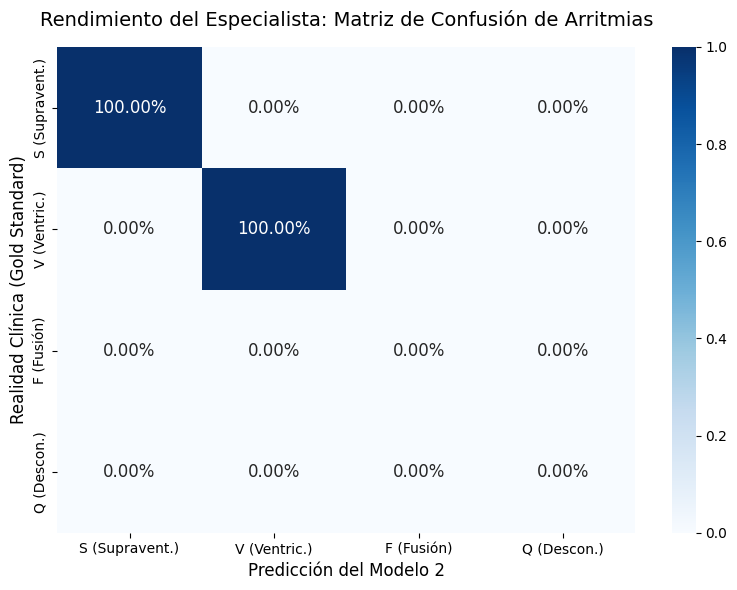


REPORTE DE CLASIFICACIÓN DEL MODELO 2 (ESPECIALISTA EN ARRITMIAS)
                precision    recall  f1-score   support

S (Supravent.)     1.0000    1.0000    1.0000         1
  V (Ventric.)     1.0000    1.0000    1.0000       115
    F (Fusión)     0.0000    0.0000    0.0000         0
   Q (Descon.)     0.0000    0.0000    0.0000         0

      accuracy                         1.0000       116
     macro avg     0.5000    0.5000    0.5000       116
  weighted avg     1.0000    1.0000    1.0000       116


F1-Score Macro Global del Especialista: 0.5000


c:\Users\Israel\Desktop\ecg-lstm-pipeline\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Israel\Desktop\ecg-lstm-pipeline\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Israel\Desktop\ecg-lstm-pipeline\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

In [ ]:
# %%
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tensorflow.keras.models import load_model

# ==========================================
# 1. CARGA DEL MODELO COMPLETADO DE 5 CLASES
# ==========================================
print("Cargando el mejor modelo multiclase unificado...")
model_path = "../models/classificator_v1_mc_rr_w1500_s40k_5c_augmented.keras"

model_eval = load_model(
    model_path,
    custom_objects={'loss': poly_focal_loss(gamma=2.0, epsilon=0.5, alpha_weights=weights_vector_multi)}
)

# ==========================================
# 2. PREDICCIONES SOBRE EL SET DE TEST REAL
# ==========================================
print("Realizando predicciones sobre el set de test global...")
y_pred_raw = model_eval.predict([X_test_sig_norm, X_test_rr_final_norm])

y_pred = np.argmax(y_pred_raw, axis=-1)
y_true = np.argmax(y_test_m2_onehot, axis=-1) 

labels_m2 = [0, 1, 2, 3, 4]
classes_m2_names = ['Normal', 'S (Supravent.)', 'V (Ventric.)', 'F (Fusión)', 'Q (Descon.)']

# ==========================================
# 3. MATRIZ DE CONFUSIÓN GLOBAL NORMALIZADA
# ==========================================
cm = confusion_matrix(y_true, y_pred, labels=labels_m2, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues', 
    xticklabels=classes_m2_names, 
    yticklabels=classes_m2_names,
    annot_kws={"size": 12}
)
plt.title('Rendimiento del Sistema Global: Matriz de Confusión Unificada', fontsize=14, pad=15)
plt.ylabel('Realidad Clínica (Gold Standard)', fontsize=12)
plt.xlabel('Predicción de la Red Multimodal', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 4. REPORTE DE RENDIMIENTO DEL TFG
# ==========================================
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN GLOBAL (5 CATEGORÍAS AAMI)")
print("="*60)
print(classification_report(y_true, y_pred, labels=labels_m2, target_names=classes_m2_names, digits=4))

macro_f1_global = f1_score(y_true, y_pred, labels=labels_m2, average='macro')
print(f"\nF1-Score Macro Global del Sistema: {macro_f1_global:.4f}")